In [1]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# ============================================================
# STEP 2: LOAD BRENT DAILY DATASET
# ============================================================

# Change path according to your dataset
brent_daily = pd.read_csv(
    "cleaned_datasets/brent_daily_clean.csv"
)

print(brent_daily.head())
print(brent_daily.info())

         Date  Price
0  1987-05-20  18.63
1  1987-05-21  18.45
2  1987-05-22  18.55
3  1987-05-25  18.60
4  1987-05-26  18.63
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9922 entries, 0 to 9921
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9922 non-null   object 
 1   Price   9922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 155.2+ KB
None


Index(['Price'], dtype='object')


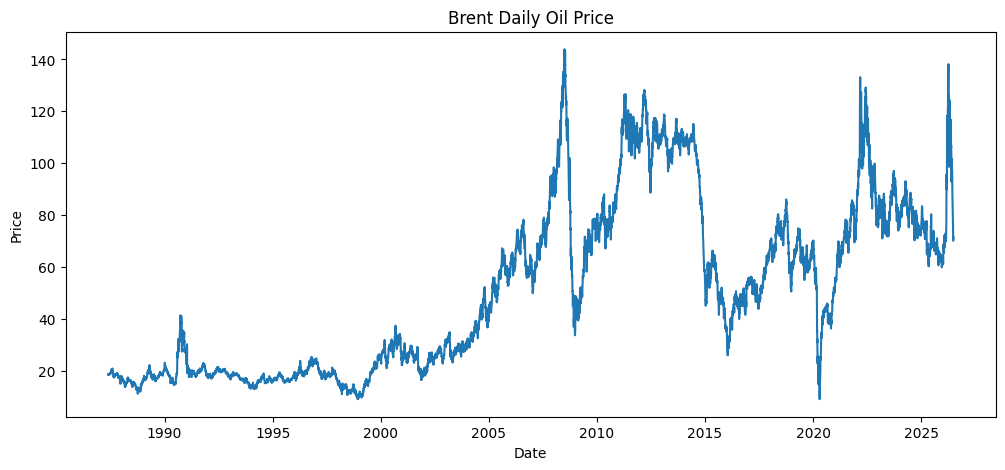

In [3]:
# ============================================================
# STEP 3: DATA PREPROCESSING
# ============================================================

# Convert Date column to datetime
brent_daily['Date'] = pd.to_datetime(
    brent_daily['Date']
)

# Sort according to date
brent_daily = brent_daily.sort_values(
    'Date'
)

# Set Date as index
brent_daily.set_index(
    'Date',
    inplace=True
)


# Check columns
print(brent_daily.columns)


# Select oil price column
# Change "Price" if your column has another name
oil_price = brent_daily[['Price']]


# Visualize original data

plt.figure(figsize=(12,5))

plt.plot(
    oil_price
)

plt.title("Brent Daily Oil Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [4]:
# ============================================================
# STEP 4: TRAIN TEST SPLIT
# ============================================================

# Use 80% data for training and 20% for testing
train_size = int(
    len(oil_price) * 0.8
)


train = oil_price.iloc[:train_size]

test = oil_price.iloc[train_size:]


print("Training size:", train.shape)
print("Testing size:", test.shape)

Training size: (7937, 1)
Testing size: (1985, 1)


In [5]:

# ============================================================
# STEP 5: NORMALIZATION USING MIN-MAX SCALER
# ============================================================

# LSTM works better with scaled data

scaler = MinMaxScaler(
    feature_range=(0,1)
)


# Fit only on training data
train_scaled = scaler.fit_transform(
    train
)


# Transform test data
test_scaled = scaler.transform(
    test
)



In [6]:
# ============================================================
# STEP 6: CREATE SEQUENCES FOR LSTM
# ============================================================

# Previous 60 days are used to predict next day

time_steps = 60


def create_sequences(data, time_steps):

    X = []
    y = []

    for i in range(time_steps, len(data)):

        # Previous days
        X.append(
            data[i-time_steps:i,0]
        )

        # Next day price
        y.append(
            data[i,0]
        )

    return np.array(X), np.array(y)



X_train, y_train = create_sequences(
    train_scaled,
    time_steps
)


X_test, y_test = create_sequences(
    test_scaled,
    time_steps
)



print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)

X_train shape: (7877, 60)
y_train shape: (7877,)
X_test shape: (1925, 60)


In [7]:
# ============================================================
# STEP 7: RESHAPE DATA FOR LSTM
# ============================================================

# LSTM requires:
# Samples x Time steps x Features

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)


X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)


In [8]:
# ============================================================
# STEP 8: BUILD LSTM MODEL
# ============================================================


model = Sequential()


# First LSTM layer
model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(time_steps,1)
    )
)


model.add(
    Dropout(0.2)
)


# Second LSTM layer

model.add(
    LSTM(
        units=50
    )
)


model.add(
    Dropout(0.2)
)


# Output layer

model.add(
    Dense(1)
)



# Display model architecture

model.summary()



C:\Users\ranpa\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ============================================================
# STEP 9: COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


In [11]:
# ============================================================
# STEP 10: TRAIN LSTM MODEL
# ============================================================


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


history = model.fit(

    X_train,
    y_train,

    epochs=10,

    batch_size=32,

    validation_split=0.2,

    callbacks=[early_stop],

    verbose=1

)


Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0011 - val_loss: 4.5633e-04
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - loss: 9.4007e-04 - val_loss: 5.1113e-04
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 24s 120ms/step - loss: 8.7979e-04 - val_loss: 0.0010
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - loss: 7.7836e-04 - val_loss: 0.0011
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - loss: 7.8243e-04 - val_loss: 7.1132e-04
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 49s 169ms/step - loss: 7.0853e-04 - val_loss: 4.0706e-04
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 37s 149ms/step - loss: 6.5957e-04 - val_loss: 2.7562e-04
Epoch 9/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 35s 179ms/step - loss: 7.0680e-04 - val_loss: 4.9442e-04
Epoch 10/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 25s 129ms/step - loss: 6.4985e-04 - val_loss: 5.4498e-04


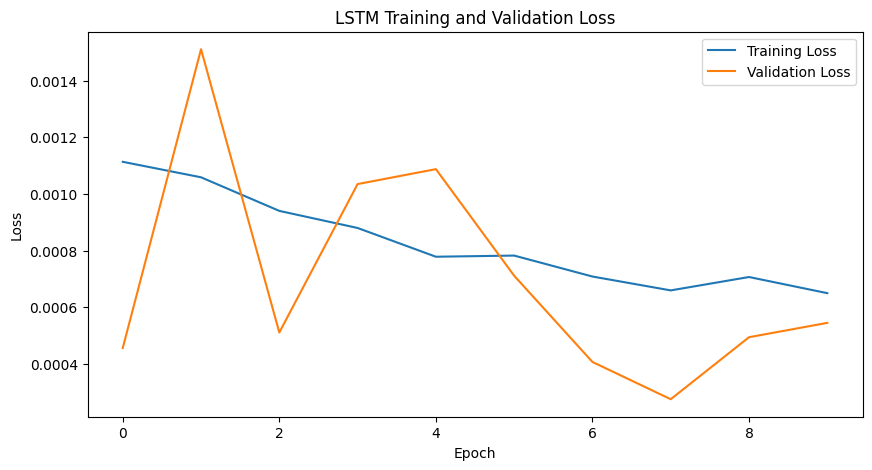

In [12]:
# ============================================================
# STEP 11: TRAINING LOSS VISUALIZATION
# ============================================================


plt.figure(figsize=(10,5))


plt.plot(
    history.history['loss'],
    label="Training Loss"
)


plt.plot(
    history.history['val_loss'],
    label="Validation Loss"
)


plt.title(
    "LSTM Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [13]:
# ============================================================
# STEP 12: MAKE PREDICTIONS
# ============================================================


predictions = model.predict(
    X_test
)

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


In [14]:
# ============================================================
# STEP 13: REVERSE SCALING
# ============================================================


predicted_prices = scaler.inverse_transform(
    predictions
)


actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)


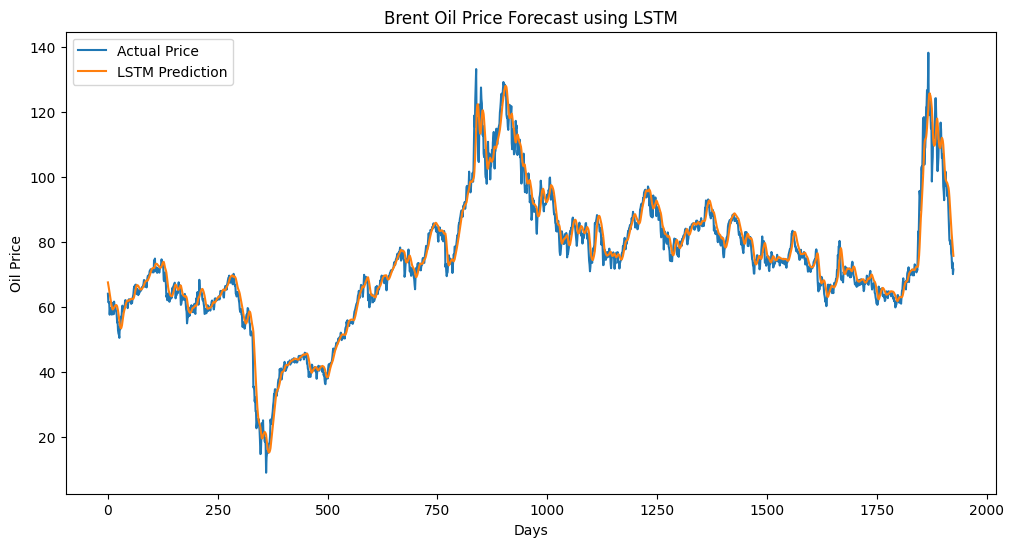

In [15]:

# ============================================================
# STEP 14: VISUALIZE ACTUAL VS PREDICTED VALUES
# ============================================================


plt.figure(figsize=(12,6))


plt.plot(
    actual_prices,
    label="Actual Price"
)


plt.plot(
    predicted_prices,
    label="LSTM Prediction"
)


plt.title(
    "Brent Oil Price Forecast using LSTM"
)

plt.xlabel(
    "Days"
)

plt.ylabel(
    "Oil Price"
)

plt.legend()

plt.show()

In [16]:
# ============================================================
# STEP 15: MODEL EVALUATION
# ============================================================


# MAE

mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)


# RMSE

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices
    )
)


# MAPE

mape = np.mean(

    np.abs(
        (actual_prices - predicted_prices)
        /
        actual_prices
    )

) * 100



print("==============================")
print("LSTM MODEL PERFORMANCE")
print("==============================")

print("MAE :", mae)

print("RMSE:", rmse)

print("MAPE:", mape, "%")





LSTM MODEL PERFORMANCE
MAE : 2.464286225811847
RMSE: 3.601829499311053
MAPE: 3.624062416831199 %


In [17]:
# ============================================================
# STEP 16: SAVE MODEL
# ============================================================


model.save(
    "brent_daily_lstm_model.h5"
)


print("Model saved successfully!")

Model saved successfully!
